## Test notebook

For testing the Perceptron class and its methods

Initializing Perceptron
Learning Rate: 0.5
Number of Epochs: 1000
Input with Bias: [[ 1.  2.  1.]
 [ 1. -1.  1.]
 [ 1. -1. -1.]
 [ 1.  1.  1.]
 [ 1.  2.  2.]
 [ 1. -2. -1.]]
Initial Weights: [ 0.14682101 -0.66969704  0.17025298]
----------------------------------------
Epoch 1/1000
Input: [1. 2. 1.], Output: 1
Weighted Sum: -1.0223200898184301
Predicted Output: 0
Error: 1
Updated Weights: [0.64682101 0.33030296 0.67025298]
Input: [ 1. -1.  1.], Output: 0
Weighted Sum: 0.986771021057832
Predicted Output: 1
Error: -1
Updated Weights: [0.14682101 0.83030296 0.17025298]
Input: [ 1. -1. -1.], Output: 0
Weighted Sum: -0.8537349359877346
Predicted Output: 0
Error: 0
No weight update needed
Input: [1. 1. 1.], Output: 1
Weighted Sum: 1.147376947140324
Predicted Output: 1
Error: 0
No weight update needed
Input: [1. 2. 2.], Output: 1
Weighted Sum: 2.147932888704353
Predicted Output: 1
Error: 0
No weight update needed
Input: [ 1. -2. -1.], Output: 0
Weighted Sum: -1.6840378990289806
Predicted Outp

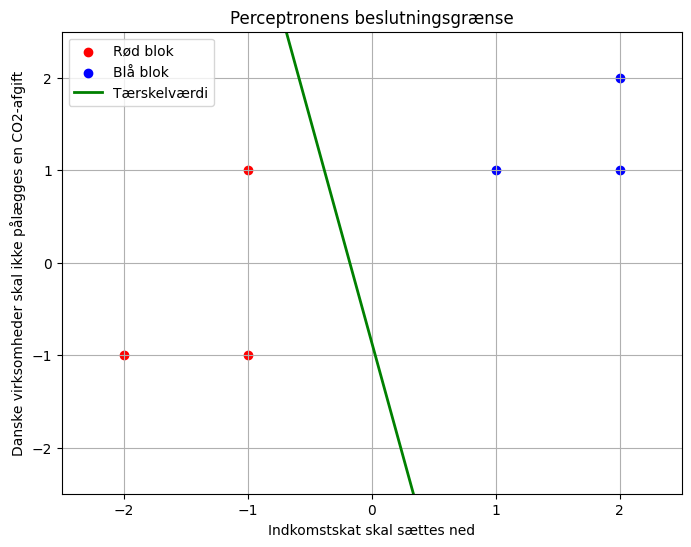

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from perceptron import Perceptron

def heaviside_step(x):
    # Heaviside step function
    return 1 if x >= 0 else 0


def plot_decision_boundary(weights, X, y):
    # Extract weights
    w0, w1, w2 = weights

    # Formula (with only 2D data): w0 + w1*x1 + w2*x2 = 0
    # Rearranging gives: x2 = -(w0/w2) - (w1/w2)*x1
    x1_values = np.linspace(-2.5, 2.5, 100)
    x2_values = -(w0 / w2) - (w1 / w2) * x1_values

    # Formula:
    print(f"Decision Boundary: x2 = {-(w0 / w2)} - ({w1 / w2}) * x1")
    print(f"Decision Boundary: 0 = {w0} + {w1} * x1 + {w2} * x2")


    # Plot data points
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Rød blok')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Blå blok')

    # Plot decision boundary
    plt.plot(x1_values, x2_values, color='green', label='Tærskelværdi', linewidth=2)

    # Axis labels and legend
    plt.xlabel('Indkomstskat skal sættes ned')
    plt.ylabel('Danske virksomheder skal ikke pålægges en CO2-afgift')
    plt.title('Perceptronens beslutningsgrænse')
    plt.xlim(-2.5, 2.5)
    plt.ylim(-2.5, 2.5)
    plt.legend()
    plt.grid(True)
    plt.show()

def main():
    learning_rate = 0.5
    n_epochs = 1000
    activation_function = heaviside_step
    init_weight_value = np.random.uniform(-1, 1, 3)  # Random initialization of weights



    # Initialize the perceptron with 2 input features
    p = Perceptron(learning_rate, n_epochs, activation_function, init_weight_value)

    # Train the perceptron with some sample data 'kandidattest' from aimat.dk
    # "From a scale of -2 to 2, how much do you agree with this political statement?"
    test_data = np.array([
        [2, 1],
        [-1, 1],
        [-1, -1],
        [1, 1],
        [2, 2],
        [-2, -1]
    ])
    
    target_labels = np.array([1, 0, 0, 1, 1, 0])  # Example labels for the test data
    

    p.fit(test_data, target_labels)

    # for inputs in test_data:
    #     print(f"Input: {inputs}, Prediction: {p.predict(inputs)}")
    # Print the perceptron structure
    p.print_structure()

    plot_decision_boundary(p.weights, test_data, target_labels)

    p.score(test_data, target_labels)
    # Calculate confusion matrix
    y_true = target_labels
    y_pred = p.predict(test_data)

    p.confusion_matrix(y_true, y_pred)
    


if __name__ == "__main__":
    main()